# Fair MLP, LSTM, and TCN comparison: DeFOG

## Question answered

On subjects absent from training, how many real freezing-of-gait
episodes does each model correctly detect, and how many false alarms
does that sensitivity cost?

This notebook is separate from the historical baseline notebooks. It
makes MLP, LSTM, and TCN results comparable by fixing the subject folds,
two-second causal inputs, prediction endpoints, preprocessing, class and
subject weighting, optimiser, loss, epoch budget, seeds, decoder search,
and episode evaluator.

The primary target is AnyFoG: StartHesitation OR Turn OR Walking. Event
type is an identically weighted auxiliary training head for all models.

Run from top to bottom in a VS Code WSL window with the
Dissertation FoG GPU (WSL2) kernel.

## 1. Setup and environment check

In [1]:
from pathlib import Path
import gc
import importlib
import sys

import numpy as np

print(f"Python executable: {sys.executable}")
print(f"NumPy version: {np.__version__}")
if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        "This notebook requires NumPy 1.26.x. Reopen the project in WSL, "
        "select 'Dissertation FoG GPU (WSL2)', and restart the notebook."
    )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")
GPU_DEVICES = tf.config.list_physical_devices("GPU")
print(f"TensorFlow devices: {tf.config.list_physical_devices()}")
if not GPU_DEVICES:
    raise RuntimeError(
        "No GPU is visible. Reopen this project in WSL and select the "
        "'Dissertation FoG GPU (WSL2)' kernel."
    )
for gpu_device in GPU_DEVICES:
    try:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    except RuntimeError:
        pass
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "fog_pipeline.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

importlib.invalidate_caches()
import fog_pipeline as _fog_pipeline
_fog_pipeline = importlib.reload(_fog_pipeline)
import fair_benchmark as _fair_benchmark
_fair_benchmark = importlib.reload(_fair_benchmark)

from fog_pipeline import (
    ANY_FOG_COLUMN,
    SEGMENT_COLUMN,
    SENSOR_COLUMNS,
    TARGET_COLUMNS,
    load_recordings,
)
from fair_benchmark import (
    ALARM_BUDGET_OPERATING_POINT,
    ARCHITECTURES,
    MODEL_FEATURES,
    PRIMARY_OPERATING_POINT,
    BenchmarkSettings,
    assign_subject_outer_folds,
    build_benchmark_model,
    causal_downsample_recordings,
    run_fair_benchmark,
    subject_partitions_for_fold,
    validate_benchmark_data,
)

Python executable: /home/rahul/.venvs/dissertation-gpu/bin/python
NumPy version: 1.26.4


2026-07-29 18:48:00.211166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-29 18:48:00.629474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-29 18:48:00.802809: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-29 18:48:00.856306: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-29 18:48:01.112950: I tensorflow/core/platform/cpu_feature_guar

TensorFlow devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Fixed dataset and comparison profile

In [2]:
DATASET_NAME = 'defog'
RECORDINGS_DIR = PROJECT_ROOT / "data" / "raw" / "train" / 'defog'
METADATA_PATH = PROJECT_ROOT / "data" / "metadata" / 'defog_metadata.csv'
NATIVE_SAMPLING_RATE_HZ = 100.0
FILTER_VALID_TASK = True

# comparison is the requested five-fold, one-seed result. pilot is a quick
# wiring check. ensemble_3 averages three seeds for every model, never only one.
RUN_PROFILE = "comparison"  # "pilot", "comparison", or "ensemble_3"
PROFILE_SETTINGS = {
    "pilot": {"folds": (0,), "seeds": (42,)},
    "comparison": {"folds": tuple(range(5)), "seeds": (42,)},
    "ensemble_3": {"folds": tuple(range(5)), "seeds": (42, 52, 62)},
}
if RUN_PROFILE not in PROFILE_SETTINGS:
    raise ValueError("Unknown RUN_PROFILE")
ACTIVE_PROFILE = PROFILE_SETTINGS[RUN_PROFILE]

SETTINGS = BenchmarkSettings(
    native_sampling_rate_hz=NATIVE_SAMPLING_RATE_HZ,
    benchmark_sampling_rate_hz=25.0,
    folds_to_run=ACTIVE_PROFILE["folds"],
    ensemble_seeds=ACTIVE_PROFILE["seeds"],
    epochs=40,
    early_stopping_patience=8,
)
SETTINGS.validate()
RUN_TRAINING = True

fit_count = (
    len(SETTINGS.folds_to_run)
    * len(SETTINGS.ensemble_seeds)
    * len(ARCHITECTURES)
)
print(
    {
        "dataset": DATASET_NAME,
        "profile": RUN_PROFILE,
        "models": ARCHITECTURES,
        "outer_folds": SETTINGS.folds_to_run,
        "shared_seeds": SETTINGS.ensemble_seeds,
        "total_model_fits": fit_count,
        "maximum_epochs_per_fit": SETTINGS.epochs,
        "early_stopping_patience": SETTINGS.early_stopping_patience,
        "common_window": (
            SETTINGS.window_samples,
            len(MODEL_FEATURES),
        ),
    }
)
print(
    "Forty is the maximum epoch count. Early stopping may finish a fit earlier "
    "after eight non-improving validation epochs; there is no three-epoch cap."
)

{'dataset': 'defog', 'profile': 'comparison', 'models': ('MLP', 'LSTM', 'TCN'), 'outer_folds': (0, 1, 2, 3, 4), 'shared_seeds': (42,), 'total_model_fits': 15, 'maximum_epochs_per_fit': 40, 'early_stopping_patience': 8, 'common_window': (50, 4)}
Forty is the maximum epoch count. Early stopping may finish a fit earlier after eight non-improving validation epochs; there is no three-epoch cap.


## 3. Load, validate, and causally standardise time

The native rows are aggregated into preceding-time bins at about 25 Hz.
Every retained sensor value uses only samples at or before its endpoint.
The first 49 endpoints of each contiguous segment are excluded for all
models, so every prediction has the same complete 50-bin window.

In [3]:
native_data = load_recordings(
    RECORDINGS_DIR,
    METADATA_PATH,
    limit_recordings=None,
    filter_valid_task=FILTER_VALID_TASK,
    assume_recording_is_subject=False,
)
validate_benchmark_data(native_data)

native_structure = pd.DataFrame(
    {
        "dataset": [DATASET_NAME],
        "recordings": [native_data["RecordingId"].nunique()],
        "subjects": [native_data["Subject"].nunique()],
        "native_rows": [len(native_data)],
        "missing_sensor_values": [
            int(native_data.loc[:, SENSOR_COLUMNS].isna().sum().sum())
        ],
        "duplicate_recording_times": [
            int(native_data.duplicated(["RecordingId", "Time"]).sum())
        ],
    }
)
display(native_structure)

benchmark_data = causal_downsample_recordings(native_data, SETTINGS)
del native_data
gc.collect()

subject_manifest, FOLD_STRATEGY = assign_subject_outer_folds(
    benchmark_data, SETTINGS
)
print(f"Outer-fold strategy: {FOLD_STRATEGY}")
print(
    f"Causal benchmark grid: {len(benchmark_data):,} endpoints at about "
    f"{SETTINGS.benchmark_sampling_rate_hz:g} Hz"
)

# This display is structural only. Test outcome rates are not shown during EDA.
display(
    subject_manifest.loc[:, ["Subject", "recordings", "rows", "OuterFold"]]
    .sort_values(["OuterFold", "Subject"], kind="stable")
    .reset_index(drop=True)
)

,dataset,recordings,subjects,native_rows,missing_sensor_values,duplicate_recording_times
0,defog,91,38,4090530,0,0


Outer-fold strategy: burden-stratified
Causal benchmark grid: 1,023,088 endpoints at about 25 Hz


,Subject,recordings,rows,OuterFold
0,00f674,4,33901,0
1,08de77,1,12755,0
2,107712,2,25154,0
3,2874c5,4,31384,0
4,58e067,2,8280,0
5,7da72f,2,23652,0
6,a50c72,2,22961,0
7,bb3387,2,33458,0
8,1d7a0d,1,5118,1
9,3a90e2,4,37845,1


## 4. Frozen subject partitions and leakage assertions

In [4]:
partition_rows = []
partition_subject_sets = {}
for outer_fold in range(SETTINGS.n_outer_folds):
    partitions = subject_partitions_for_fold(
        subject_manifest, outer_fold, SETTINGS
    )
    partition_subject_sets[outer_fold] = partitions
    for partition_name, subjects in partitions.items():
        subset = benchmark_data.loc[
            benchmark_data["Subject"].astype(str).isin(subjects)
        ]
        partition_rows.append(
            {
                "outer_fold": outer_fold,
                "partition": partition_name,
                "subjects": len(subjects),
                "recordings": subset["RecordingId"].nunique(),
                "benchmark_rows": len(subset),
            }
        )

partition_structure = pd.DataFrame(partition_rows)
display(partition_structure)

for outer_fold, partitions in partition_subject_sets.items():
    names = list(partitions)
    for left_index, left_name in enumerate(names):
        for right_name in names[left_index + 1:]:
            assert not (partitions[left_name] & partitions[right_name]), (
                outer_fold,
                left_name,
                right_name,
            )
print("PASS: train, early-stop, calibration, and test subjects are disjoint.")

,outer_fold,partition,subjects,recordings,benchmark_rows
0,0,train,22,53,555909
1,0,early_stop,4,9,129272
2,0,calibration,4,10,146362
3,0,test,8,19,191545
4,1,train,22,50,542273
5,1,early_stop,4,11,96184
6,1,calibration,4,11,108997
7,1,test,8,19,275634
8,2,train,23,54,661529
9,2,early_stop,4,9,105127


PASS: train, early-stop, calibration, and test subjects are disjoint.


## 5. Protocol-frozen exploratory EDA: labels and subject variation

This uses only fold 0's training partition, not its calibration or test
subjects. In five-fold cross-validation those same people are held out in
other folds, so treat this as retrospective EDA and do not revise the now-
frozen protocol after inspecting it.

EDA uses 22 fold-0 training subjects; do not revise the frozen protocol after viewing these outcomes.


,positive_rows,positive_rate
StartHesitation,92,0.000165
Turn,91082,0.163843
Walking,7000,0.012592
AnyFoG,98174,0.176601


,Subject,recordings,rows,any_fog_rate
count,22,22.000000,22.000000,22.000000
unique,22,NaN,NaN,NaN
top,040587,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,2.409091,25268.590909,0.158472
std,NaN,0.959121,13590.409530,0.126428
min,NaN,1.000000,7746.000000,0.006143
25%,NaN,2.000000,15218.000000,0.044806
50%,NaN,2.000000,23717.000000,0.144495
75%,NaN,3.000000,30553.750000,0.260274


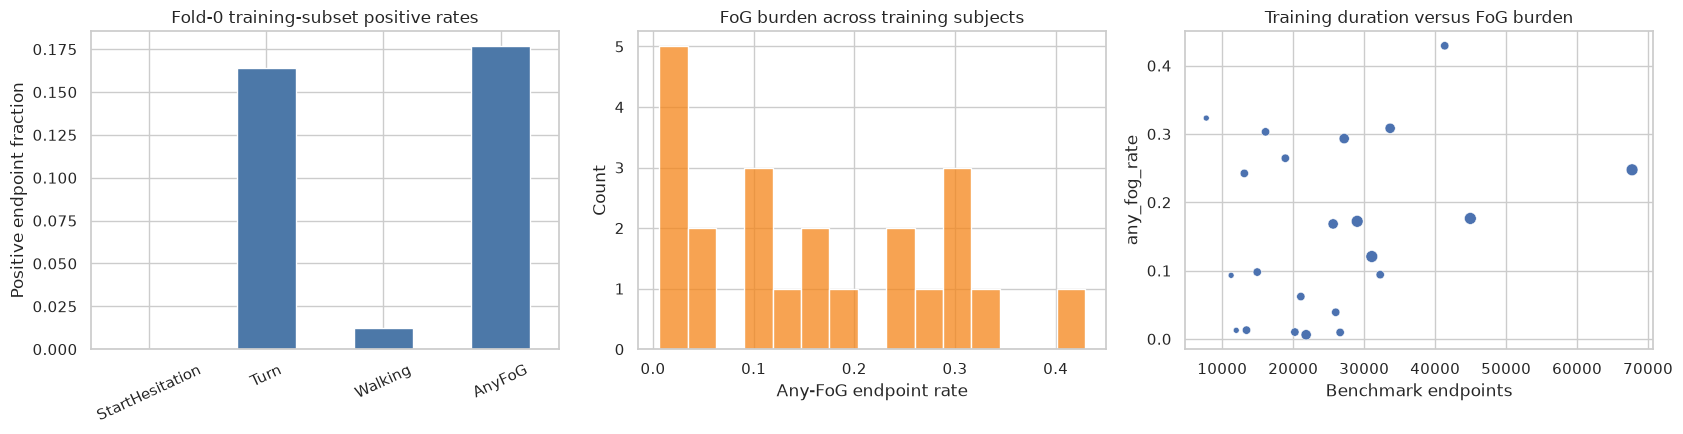

In [5]:
# Protocol-frozen retrospective EDA uses the training subjects of one fold only.
EDA_OUTER_FOLD = SETTINGS.folds_to_run[0]
eda_subjects = partition_subject_sets[EDA_OUTER_FOLD]["train"]
eda_data = benchmark_data.loc[
    benchmark_data["Subject"].astype(str).isin(eda_subjects)
].copy()
print(
    f"EDA uses {len(eda_subjects)} fold-{EDA_OUTER_FOLD} training subjects; "
    "do not revise the frozen protocol after viewing these outcomes."
)

label_summary = pd.DataFrame(
    {
        "positive_rows": eda_data.loc[:, TARGET_COLUMNS].sum(),
        "positive_rate": eda_data.loc[:, TARGET_COLUMNS].mean(),
    }
)
label_summary.loc[ANY_FOG_COLUMN] = {
    "positive_rows": int(eda_data[ANY_FOG_COLUMN].sum()),
    "positive_rate": float(eda_data[ANY_FOG_COLUMN].mean()),
}
display(label_summary)

subject_burden = (
    eda_data.groupby("Subject", observed=True)
    .agg(
        recordings=("RecordingId", "nunique"),
        rows=("Time", "size"),
        any_fog_rate=(ANY_FOG_COLUMN, "mean"),
    )
    .reset_index()
)
display(subject_burden.describe(include="all"))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
label_summary["positive_rate"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Fold-0 training-subset positive rates")
axes[0].set_ylabel("Positive endpoint fraction")
axes[0].tick_params(axis="x", rotation=25)

sns.histplot(
    data=subject_burden,
    x="any_fog_rate",
    bins=min(15, max(5, len(subject_burden))),
    ax=axes[1],
    color="#f58518",
)
axes[1].set_title("FoG burden across training subjects")
axes[1].set_xlabel("Any-FoG endpoint rate")

sns.scatterplot(
    data=subject_burden,
    x="rows",
    y="any_fog_rate",
    size="recordings",
    ax=axes[2],
    legend=False,
)
axes[2].set_title("Training duration versus FoG burden")
axes[2].set_xlabel("Benchmark endpoints")
plt.tight_layout()
plt.show()

## 6. Protocol-frozen EDA: sensor distributions and correlations

,count,mean,std,min,1%,5%,50%,95%,99%,max
AccV,200000.0,-0.939914,0.100038,-2.679397,-1.244826,-1.084399,-0.947879,-0.776636,-0.664804,0.112219
AccML,200000.0,0.033023,0.123440,-0.903314,-0.280917,-0.163763,0.034531,0.230932,0.332681,0.997822
AccAP,200000.0,-0.205142,0.239631,-1.466290,-0.690368,-0.543788,-0.228230,0.255845,0.424979,0.814890


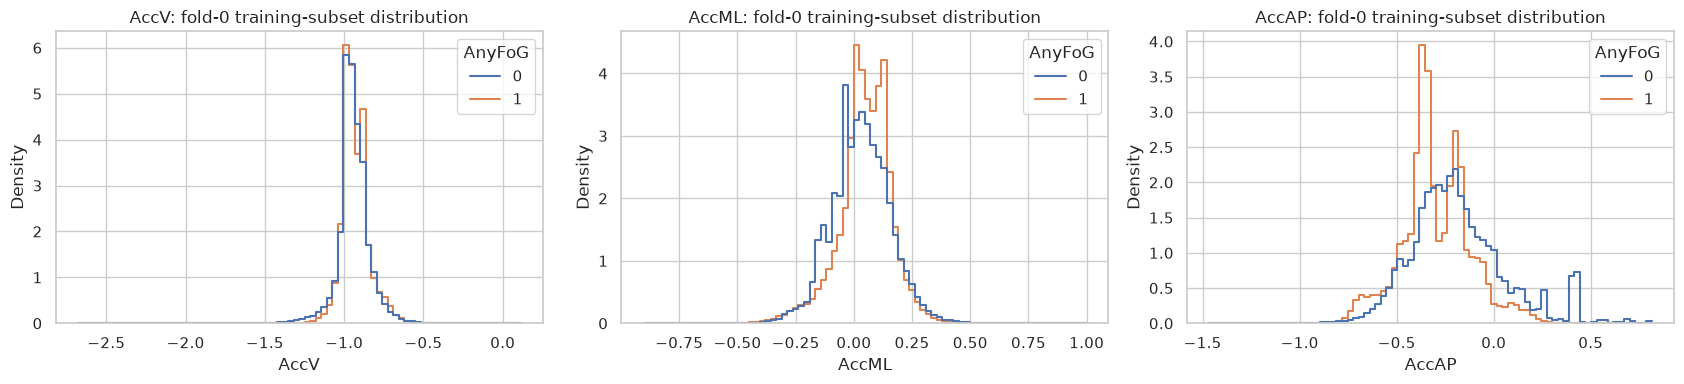

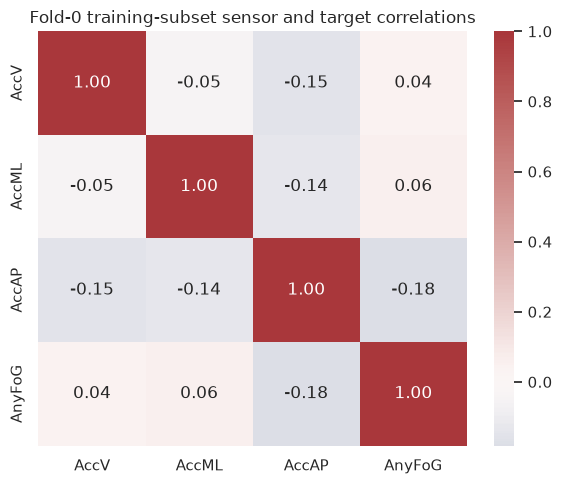

In [6]:
sample_size = min(200_000, len(eda_data))
eda_sample = eda_data.sample(n=sample_size, random_state=SETTINGS.random_state)
sensor_summary = eda_sample.loc[:, SENSOR_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
display(sensor_summary)

fig, axes = plt.subplots(1, len(SENSOR_COLUMNS), figsize=(17, 4))
for axis, sensor in zip(axes, SENSOR_COLUMNS):
    sns.histplot(
        data=eda_sample,
        x=sensor,
        hue=ANY_FOG_COLUMN,
        bins=80,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=axis,
    )
    axis.set_title(f"{sensor}: fold-0 training-subset distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    eda_sample.loc[:, [*SENSOR_COLUMNS, ANY_FOG_COLUMN]].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
)
plt.title("Fold-0 training-subset sensor and target correlations")
plt.tight_layout()
plt.show()

## 7. Protocol-frozen EDA: episode duration and signal example

,duration_seconds
count,667.000000
mean,5.887151
std,10.772520
min,0.120000
10%,0.480000
25%,0.960000
50%,2.280000
75%,6.160000
90%,14.736000
max,144.560000


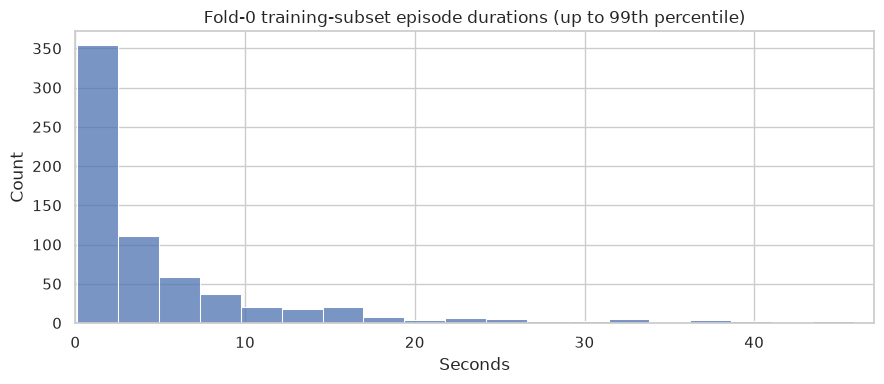

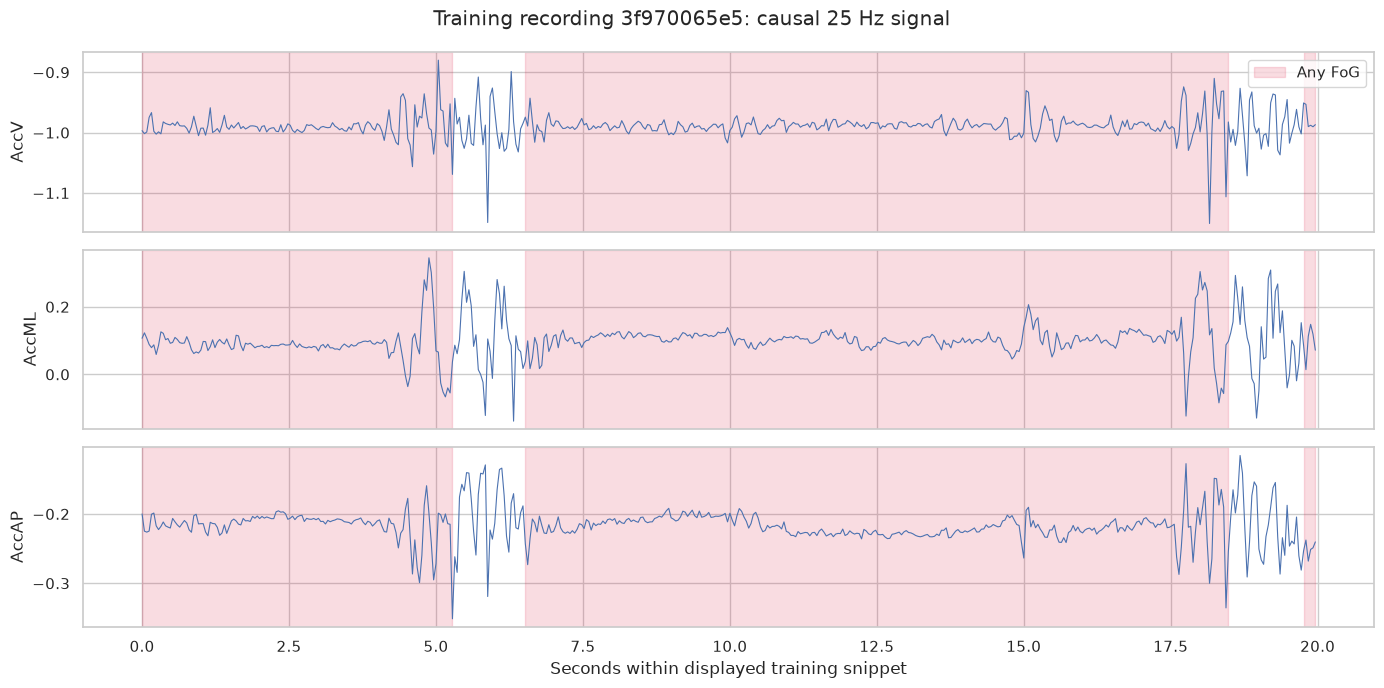

5551

In [7]:
def positive_run_durations(frame, label_column):
    duration_rows = []
    ordered = frame.sort_values(
        ["RecordingId", SEGMENT_COLUMN, "Time"], kind="stable"
    )
    for (_, _), segment in ordered.groupby(
        ["RecordingId", SEGMENT_COLUMN], sort=False, observed=True
    ):
        labels = segment[label_column].to_numpy(dtype=np.int8)
        if not labels.any():
            continue
        starts = (labels == 1) & np.r_[True, labels[:-1] == 0]
        run_ids = np.cumsum(starts)
        positive = segment.loc[labels == 1, ["Time"]].copy()
        positive["run"] = run_ids[labels == 1]
        for _, run in positive.groupby("run", sort=False):
            duration_rows.append(
                (
                    run["Time"].iloc[-1]
                    - run["Time"].iloc[0]
                    + SETTINGS.native_sampling_rate_hz
                    / SETTINGS.benchmark_sampling_rate_hz
                )
                / SETTINGS.native_sampling_rate_hz
            )
    return np.asarray(duration_rows, dtype=float)

episode_durations = positive_run_durations(eda_data, ANY_FOG_COLUMN)
if len(episode_durations):
    display(
        pd.Series(episode_durations, name="duration_seconds")
        .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
        .to_frame()
    )
    plt.figure(figsize=(9, 4))
    sns.histplot(episode_durations, bins=60)
    plt.xlim(0, np.quantile(episode_durations, 0.99))
    plt.title("Fold-0 training-subset episode durations (up to 99th percentile)")
    plt.xlabel("Seconds")
    plt.tight_layout()
    plt.show()

candidate_recordings = (
    eda_data.groupby("RecordingId", observed=True)[ANY_FOG_COLUMN]
    .sum()
    .sort_values(ascending=False)
)
snippet_recording_id = candidate_recordings.index[0]
snippet_recording = (
    eda_data.loc[eda_data["RecordingId"] == snippet_recording_id]
    .sort_values("Time", kind="stable")
    .reset_index(drop=True)
)
positive_indices = np.flatnonzero(
    snippet_recording[ANY_FOG_COLUMN].to_numpy(dtype=np.int8)
)
center = int(positive_indices[len(positive_indices) // 2]) if len(positive_indices) else 0
radius = int(10 * SETTINGS.benchmark_sampling_rate_hz)
snippet = snippet_recording.iloc[
    max(0, center - radius): min(len(snippet_recording), center + radius)
].copy()
snippet["seconds"] = (
    snippet["Time"] - snippet["Time"].iloc[0]
) / SETTINGS.native_sampling_rate_hz

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
for axis, sensor in zip(axes, SENSOR_COLUMNS):
    axis.plot(snippet["seconds"], snippet[sensor], linewidth=0.8)
    axis.fill_between(
        snippet["seconds"],
        0,
        1,
        where=snippet[ANY_FOG_COLUMN].astype(bool),
        transform=axis.get_xaxis_transform(),
        color="crimson",
        alpha=0.15,
        label="Any FoG",
    )
    axis.set_ylabel(sensor)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Seconds within displayed training snippet")
fig.suptitle(f"Training recording {snippet_recording_id}: causal 25 Hz signal")
plt.tight_layout()
plt.show()

# Release the large EDA copies before cross-validation starts.
del eda_data, eda_sample, snippet_recording, snippet
gc.collect()

## 8. Architecture and parameter-count check

In [8]:
architecture_description = pd.DataFrame(
    [
        {
            "model": "MLP",
            "temporal_operation": "Flatten the same 50 by 4 window",
        },
        {
            "model": "LSTM",
            "temporal_operation": "Unidirectional recurrence over the same window",
        },
        {
            "model": "TCN",
            "temporal_operation": "Causal residual convolutions over the same window",
        },
    ]
)
parameter_rows = []
tf.keras.utils.set_random_seed(SETTINGS.random_state)
for architecture in ARCHITECTURES:
    tf.keras.backend.clear_session()
    inspection_model = build_benchmark_model(
        architecture,
        fog_positive_weight=1.0,
        type_positive_weights=np.ones(len(TARGET_COLUMNS), dtype=np.float32),
        settings=SETTINGS,
        compile_model=False,
    )
    parameter_rows.append(
        {
            "model": architecture,
            "parameters": inspection_model.count_params(),
            "input_shape": str(inspection_model.input_shape),
            "window_seconds": SETTINGS.window_seconds,
            "features": ", ".join(MODEL_FEATURES),
        }
    )
    del inspection_model
tf.keras.backend.clear_session()

model_contract = architecture_description.merge(
    pd.DataFrame(parameter_rows), on="model", validate="one_to_one"
)
display(model_contract)
print(
    "All models use identical endpoints, raw channels, train-only scaling, "
    "weights, optimiser, losses, callbacks, seeds, and calibration rules."
)

I0000 00:00:1785347334.916817    1630 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785347334.917289    1630 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785347334.917351    1630 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785347335.162923    1630 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1785347335.163084    1630 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-29

,model,temporal_operation,parameters,input_shape,window_seconds,features
0,MLP,Flatten the same 50 by 4 window,19204,"(None, 50, 4)",2.0,"AccV, AccML, AccAP, AccMagnitude"
1,LSTM,Unidirectional recurrence over the same window,19884,"(None, 50, 4)",2.0,"AccV, AccML, AccAP, AccMagnitude"
2,TCN,Causal residual convolutions over the same window,20744,"(None, 50, 4)",2.0,"AccV, AccML, AccAP, AccMagnitude"


All models use identical endpoints, raw channels, train-only scaling, weights, optimiser, losses, callbacks, seeds, and calibration rules.


## 9. Run the fair benchmark

For every outer fold, a separate subject group controls early stopping,
another group selects the causal episode decoder, and only then are the
outer-test subjects evaluated. All three architectures are frozen before
test predictions and metrics are computed. Test labels are used beforehand
only for the prespecified burden-stratified fold assignment. The comparison
profile performs 15 fits per dataset: three models times five folds times
one common seed.

In [9]:
if not RUN_TRAINING:
    raise RuntimeError(
        "RUN_TRAINING is False. Set it to True in the configuration cell "
        "when you are ready to execute the benchmark."
    )

benchmark_results = run_fair_benchmark(
    benchmark_data,
    subject_manifest,
    SETTINGS,
    architectures=ARCHITECTURES,
    verbose=2,
)
print("Benchmark training and frozen outer-test evaluation completed.")

Outer fold 0: train=22, early-stop=4, calibration=4, test=8 subjects
Training MLP for outer fold 0
Epoch 1/40
398/398 - 28s - 70ms/step - event_type_loss: 0.3664 - fog_binary_accuracy: 0.8044 - fog_loss: 0.5948 - fog_pr_auc: 0.4139 - fog_precision: 0.4272 - fog_recall: 0.4498 - loss: 0.6682 - val_event_type_loss: 0.9979 - val_fog_binary_accuracy: 0.8176 - val_fog_loss: 0.6435 - val_fog_pr_auc: 0.2709 - val_fog_precision: 0.3164 - val_fog_recall: 0.1895 - val_loss: 0.8456 - learning_rate: 0.0010
Epoch 2/40
398/398 - 22s - 56ms/step - event_type_loss: 0.2739 - fog_binary_accuracy: 0.8322 - fog_loss: 0.4944 - fog_pr_auc: 0.5387 - fog_precision: 0.5041 - fog_recall: 0.6488 - loss: 0.5492 - val_event_type_loss: 1.0571 - val_fog_binary_accuracy: 0.7627 - val_fog_loss: 0.6453 - val_fog_pr_auc: 0.2855 - val_fog_precision: 0.3038 - val_fog_recall: 0.4545 - val_loss: 0.8593 - learning_rate: 0.0010
Epoch 3/40
398/398 - 21s - 52ms/step - event_type_loss: 0.2562 - fog_binary_accuracy: 0.8438 - fog_

2026-07-29 18:57:33.037221: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


398/398 - 37s - 92ms/step - event_type_loss: 0.4010 - fog_binary_accuracy: 0.7969 - fog_loss: 0.6486 - fog_pr_auc: 0.3552 - fog_precision: 0.3947 - fog_recall: 0.3704 - loss: 0.7290 - val_event_type_loss: 0.9599 - val_fog_binary_accuracy: 0.6439 - val_fog_loss: 0.7226 - val_fog_pr_auc: 0.2162 - val_fog_precision: 0.2339 - val_fog_recall: 0.6073 - val_loss: 0.9155 - learning_rate: 0.0010
Epoch 2/40
398/398 - 33s - 82ms/step - event_type_loss: 0.2880 - fog_binary_accuracy: 0.8147 - fog_loss: 0.5317 - fog_pr_auc: 0.4924 - fog_precision: 0.4663 - fog_recall: 0.6415 - loss: 0.5895 - val_event_type_loss: 1.0563 - val_fog_binary_accuracy: 0.6675 - val_fog_loss: 0.7327 - val_fog_pr_auc: 0.2642 - val_fog_precision: 0.2452 - val_fog_recall: 0.5891 - val_loss: 0.9468 - learning_rate: 0.0010
Epoch 3/40
398/398 - 32s - 81ms/step - event_type_loss: 0.2626 - fog_binary_accuracy: 0.8280 - fog_loss: 0.4782 - fog_pr_auc: 0.5711 - fog_precision: 0.4951 - fog_recall: 0.7164 - loss: 0.5305 - val_event_type

W0000 00:00:1785348273.822537    1885 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348273.939455    1885 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.002846    1885 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.024952    1885 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.041740    1885 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.187386    1878 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.423674    1878 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.442280    1878 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785348274.455420    1878 gp

398/398 - 66s - 167ms/step - event_type_loss: 0.3269 - fog_binary_accuracy: 0.8085 - fog_loss: 0.5655 - fog_pr_auc: 0.4562 - fog_precision: 0.4462 - fog_recall: 0.5354 - loss: 0.6311 - val_event_type_loss: 1.0203 - val_fog_binary_accuracy: 0.7842 - val_fog_loss: 0.7169 - val_fog_pr_auc: 0.2470 - val_fog_precision: 0.2772 - val_fog_recall: 0.2759 - val_loss: 0.9235 - learning_rate: 0.0010
Epoch 2/40


...

457/457 - 61s - 133ms/step - event_type_loss: 0.3326 - fog_binary_accuracy: 0.8302 - fog_loss: 0.5652 - fog_pr_auc: 0.4475 - fog_precision: 0.4482 - fog_recall: 0.4741 - loss: 0.6314 - val_event_type_loss: 0.3113 - val_fog_binary_accuracy: 0.7369 - val_fog_loss: 0.6808 - val_fog_pr_auc: 0.1707 - val_fog_precision: 0.1554 - val_fog_recall: 0.2697 - val_loss: 0.7430 - learning_rate: 0.0010
Epoch 2/40


W0000 00:00:1785354145.492197    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785354145.506645    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785354145.519116    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785354145.528121    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


457/457 - 51s - 112ms/step - event_type_loss: 0.2556 - fog_binary_accuracy: 0.8487 - fog_loss: 0.4543 - fog_pr_auc: 0.5880 - fog_precision: 0.5043 - fog_recall: 0.6829 - loss: 0.5057 - val_event_type_loss: 0.2418 - val_fog_binary_accuracy: 0.8564 - val_fog_loss: 0.5091 - val_fog_pr_auc: 0.3596 - val_fog_precision: 0.3911 - val_fog_recall: 0.3567 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 3/40
457/457 - 52s - 115ms/step - event_type_loss: 0.2346 - fog_binary_accuracy: 0.8611 - fog_loss: 0.4157 - fog_pr_auc: 0.6519 - fog_precision: 0.5337 - fog_recall: 0.7305 - loss: 0.4628 - val_event_type_loss: 0.2835 - val_fog_binary_accuracy: 0.8507 - val_fog_loss: 0.6118 - val_fog_pr_auc: 0.2972 - val_fog_precision: 0.3456 - val_fog_recall: 0.2755 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 4/40
457/457 - 52s - 114ms/step - event_type_loss: 0.2196 - fog_binary_accuracy: 0.8726 - fog_loss: 0.3891 - fog_pr_auc: 0.6914 - fog_precision: 0.5627 - fog_recall: 0.7535 - loss: 0.4328 - val_event_t

W0000 00:00:1785355131.767713    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785355131.780059    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785355131.791175    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1785355131.803873    1879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


Benchmark training and frozen outer-test evaluation completed.


## 10. Training and early-stop validation curves

Test performance is not plotted every epoch because that would turn the
test subjects into a model-selection set. Final frozen test accuracy and
episode metrics appear below.

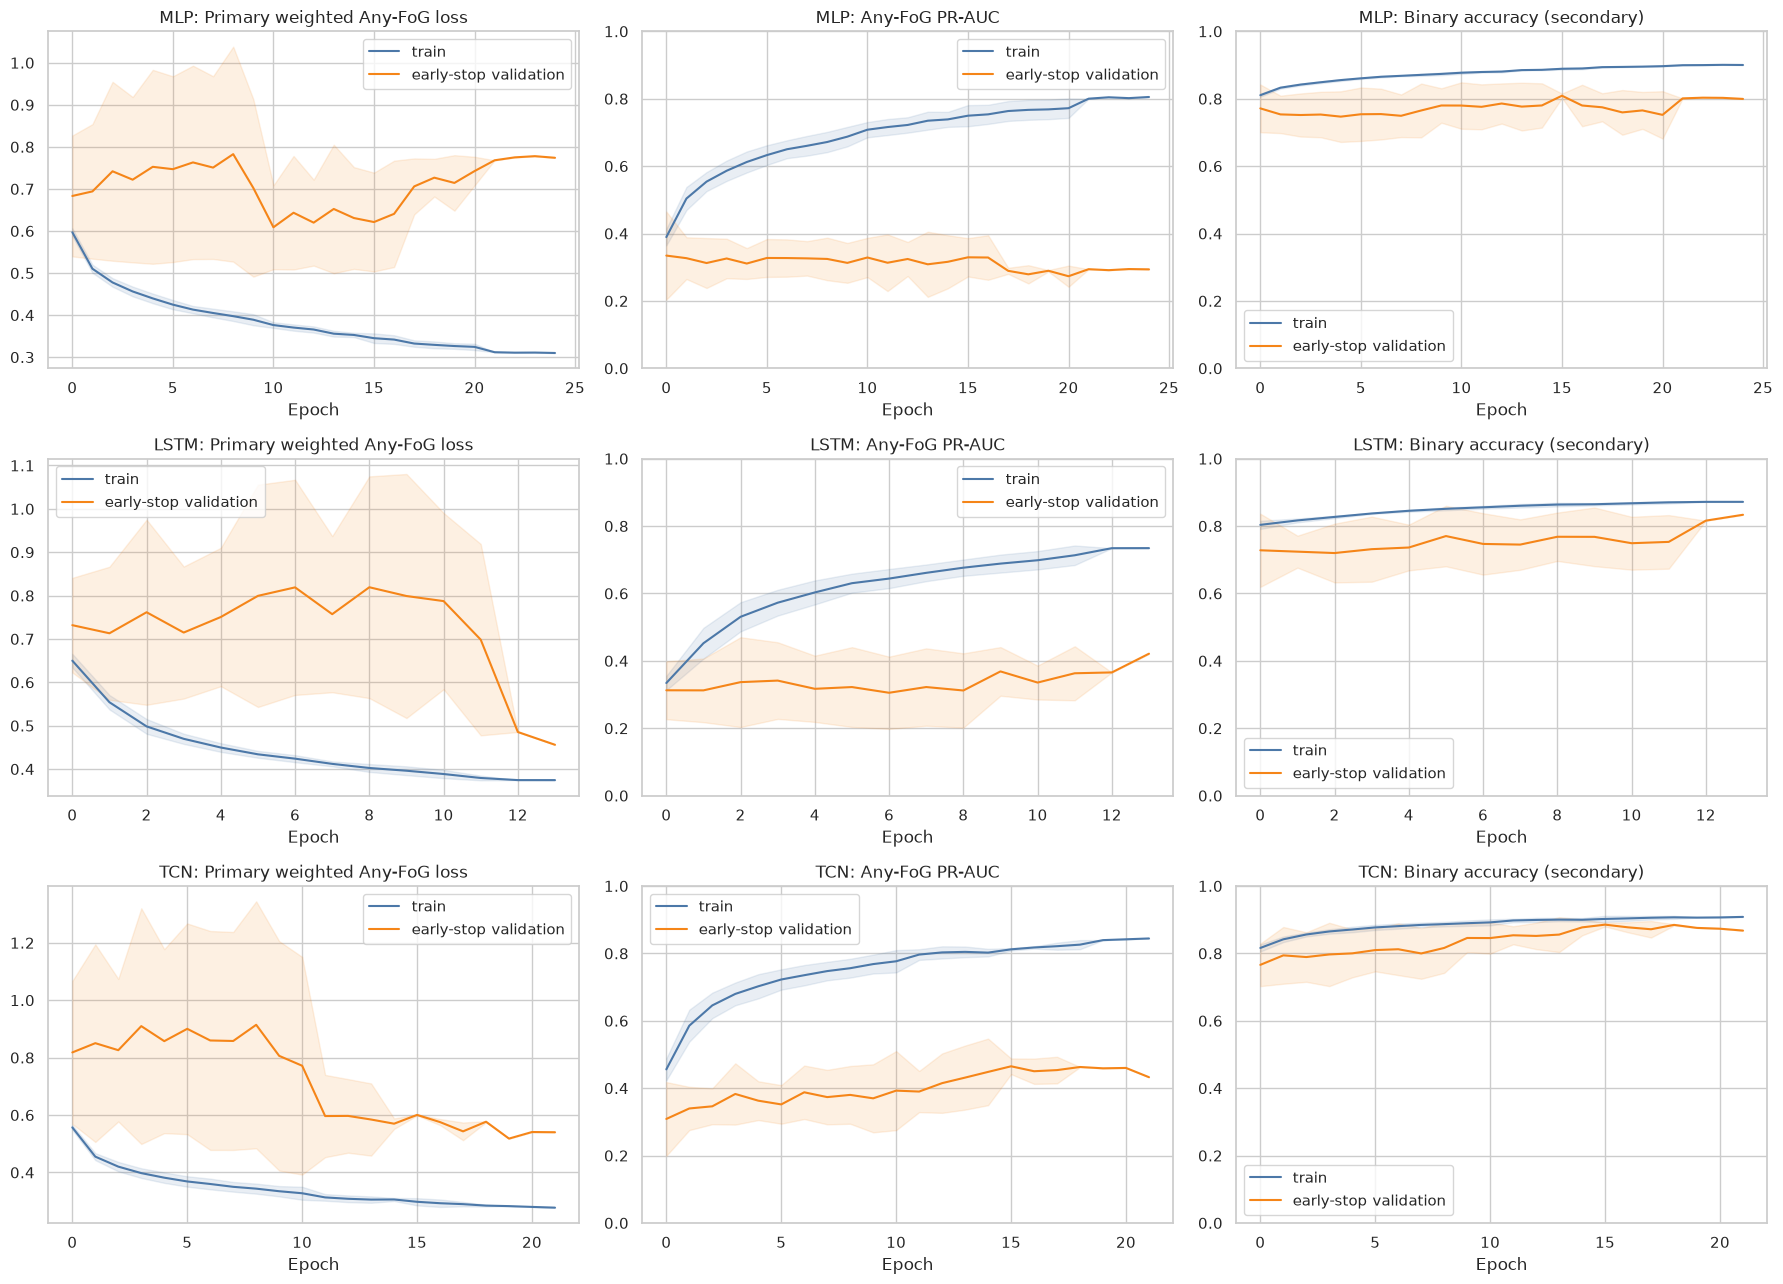

In [10]:
history = benchmark_results.histories.copy()

def metric_column(frame, metric_name, validation=False):
    expected = ("val_" if validation else "") + metric_name
    if expected in frame.columns:
        return expected
    candidates = [column for column in frame.columns if column.endswith(expected)]
    if len(candidates) != 1:
        raise KeyError(
            f"Could not uniquely locate {expected}; candidates={candidates}"
        )
    return candidates[0]

curve_specs = [
    ("fog_loss", "Primary weighted Any-FoG loss", None),
    ("fog_pr_auc", "Any-FoG PR-AUC", (0, 1)),
    ("fog_binary_accuracy", "Binary accuracy (secondary)", (0, 1)),
]
fig, axes = plt.subplots(
    len(ARCHITECTURES), len(curve_specs), figsize=(18, 13), squeeze=False
)
for row_index, architecture in enumerate(ARCHITECTURES):
    model_history = history.loc[history["model"] == architecture]
    for column_index, (metric_name, title, ylim) in enumerate(curve_specs):
        axis = axes[row_index, column_index]
        for validation, label, color in (
            (False, "train", "#4c78a8"),
            (True, "early-stop validation", "#f58518"),
        ):
            column = metric_column(model_history, metric_name, validation)
            summary = (
                model_history.groupby("epoch", observed=True)[column]
                .agg(["mean", "std"])
                .reset_index()
            )
            spread = summary["std"].fillna(0.0)
            axis.plot(summary["epoch"], summary["mean"], label=label, color=color)
            axis.fill_between(
                summary["epoch"],
                summary["mean"] - spread,
                summary["mean"] + spread,
                color=color,
                alpha=0.12,
            )
        axis.set_title(f"{architecture}: {title}")
        axis.set_xlabel("Epoch")
        if ylim is not None:
            axis.set_ylim(*ylim)
        axis.legend()
plt.tight_layout()
plt.show()

## 11. Primary held-out result: correctly detected gait episodes

Correctly detected means a one-to-one predicted/true episode match with
temporal intersection-over-union of at least 0.25. Episode recall is
detected divided by actual episodes. Binary accuracy is shown only as a
secondary timestep metric because No-FoG rows are much more common. The
primary calibration objective averages episode F1 over subjects who have
real episodes; zero-event subjects still affect its false-alarm tie-breaker
and are included directly in the alarm-budget comparison below.

,model,correctly_detected_of_actual,matched_episodes,true_episodes,missed_episodes,predicted_episodes,false_predicted_episodes,episode_recall,episode_precision,episode_f1,false_alarms_per_minute,macro_episode_recall,mean_fold_average_precision,std_fold_average_precision,mean_fold_test_weighted_fog_loss,std_fold_test_weighted_fog_loss,timestep_accuracy,timestep_balanced_accuracy,timestep_recall,timestep_f1,parameters
0,MLP,"405 / 1,243 (32.6%)",405,1243,838,5669,5264,32.6%,7.1%,0.117,8.428,27.6%,0.306,0.075,0.895,0.193,64.9%,64.6%,64.1%,0.396,19204
1,LSTM,"399 / 1,243 (32.1%)",399,1243,844,3426,3027,32.1%,11.6%,0.171,4.846,28.4%,0.343,0.076,0.746,0.101,68.2%,69.1%,70.7%,0.443,19884
2,TCN,"393 / 1,243 (31.6%)",393,1243,850,2893,2500,31.6%,13.6%,0.190,4.003,31.7%,0.332,0.061,1.056,0.406,71.1%,64.9%,55.3%,0.407,20744


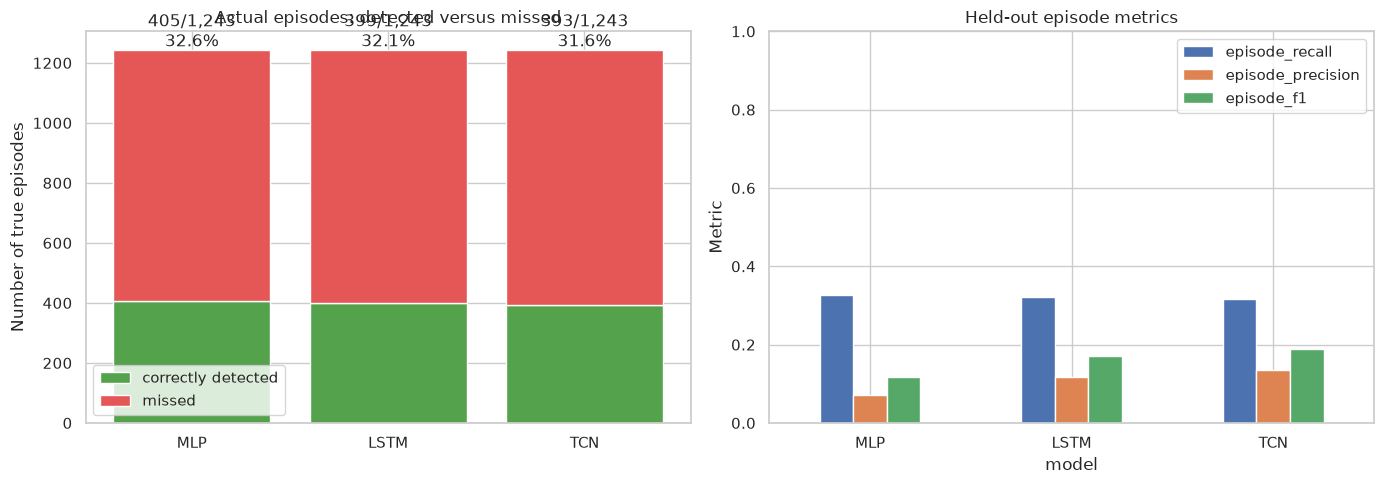

In [11]:
primary = (
    benchmark_results.overall_results
    .xs(PRIMARY_OPERATING_POINT, level="operating_point")
    .reset_index()
)
assert primary["true_episodes"].nunique() == 1, (
    "Episode denominators differ across models",
    primary[["model", "true_episodes"]],
)
primary["correctly_detected_of_actual"] = primary.apply(
    lambda row: (
        f"{int(row['matched_episodes']):,} / {int(row['true_episodes']):,} "
        f"({row['episode_recall']:.1%})"
    ),
    axis=1,
)

primary_columns = [
    "model",
    "correctly_detected_of_actual",
    "matched_episodes",
    "true_episodes",
    "missed_episodes",
    "predicted_episodes",
    "false_predicted_episodes",
    "episode_recall",
    "episode_precision",
    "episode_f1",
    "false_alarms_per_minute",
    "macro_episode_recall",
    "mean_fold_average_precision",
    "std_fold_average_precision",
    "mean_fold_test_weighted_fog_loss",
    "std_fold_test_weighted_fog_loss",
    "timestep_accuracy",
    "timestep_balanced_accuracy",
    "timestep_recall",
    "timestep_f1",
    "parameters",
]
display(primary.loc[:, primary_columns].style.format(
    {
        "episode_recall": "{:.1%}",
        "episode_precision": "{:.1%}",
        "episode_f1": "{:.3f}",
        "false_alarms_per_minute": "{:.3f}",
        "macro_episode_recall": "{:.1%}",
        "mean_fold_average_precision": "{:.3f}",
        "std_fold_average_precision": "{:.3f}",
        "mean_fold_test_weighted_fog_loss": "{:.3f}",
        "std_fold_test_weighted_fog_loss": "{:.3f}",
        "timestep_accuracy": "{:.1%}",
        "timestep_balanced_accuracy": "{:.1%}",
        "timestep_recall": "{:.1%}",
        "timestep_f1": "{:.3f}",
    }
))

figure_data = primary.set_index("model").loc[list(ARCHITECTURES)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(
    figure_data.index,
    figure_data["matched_episodes"],
    label="correctly detected",
    color="#54a24b",
)
axes[0].bar(
    figure_data.index,
    figure_data["missed_episodes"],
    bottom=figure_data["matched_episodes"],
    label="missed",
    color="#e45756",
)
for model_index, (_, row) in enumerate(figure_data.iterrows()):
    axes[0].text(
        model_index,
        row["true_episodes"] * 1.01,
        f"{int(row['matched_episodes']):,}/{int(row['true_episodes']):,}\n"
        f"{row['episode_recall']:.1%}",
        ha="center",
    )
axes[0].set_title("Actual episodes: detected versus missed")
axes[0].set_ylabel("Number of true episodes")
axes[0].legend()

metric_plot = figure_data.loc[:, ["episode_recall", "episode_precision", "episode_f1"]]
metric_plot.plot.bar(ax=axes[1], ylim=(0, 1))
axes[1].set_title("Held-out episode metrics")
axes[1].set_ylabel("Metric")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 12. Recall at a comparable false-alarm burden

The primary decoder maximises subject-macro episode F1 on calibration
subjects. This second operating point instead maximises calibration
recall subject to at most one macro false alarm per minute. The outer-test
false-alarm rate can still exceed one because it remains genuinely held out.
If no candidate meets the calibration budget, the least-alarming candidate
is retained and explicitly flagged so no model or fold silently disappears.

,model,correctly_detected_of_actual,episode_recall,episode_precision,episode_f1,false_alarms_per_minute,macro_false_alarms_per_minute
1,MLP,"76 / 1,243 (6.1%)",6.1%,6.5%,0.063,1.752,1.805
3,LSTM,"139 / 1,243 (11.2%)",11.2%,19.0%,0.141,0.946,0.931
5,TCN,"59 / 1,243 (4.7%)",4.7%,11.7%,0.068,0.711,0.732


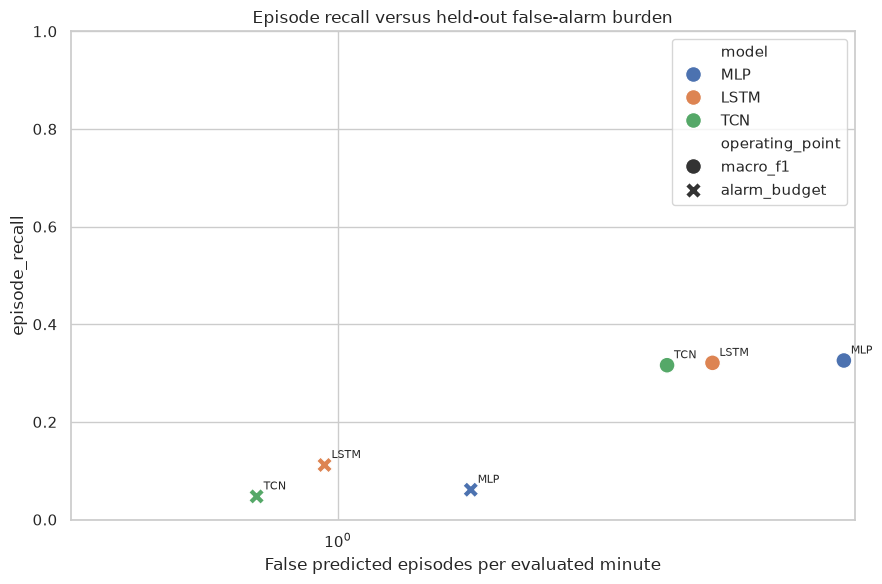

In [12]:
overall_reset = benchmark_results.overall_results.reset_index()
budget = overall_reset.loc[
    overall_reset["operating_point"] == ALARM_BUDGET_OPERATING_POINT
].copy()
budget_feasibility = (
    benchmark_results.decoder_tables
    .groupby(["outer_fold", "model"], observed=True)["alarm_budget_was_feasible"]
    .first()
)
if not budget_feasibility.all():
    print(
        "WARNING: at least one model/fold could not meet the calibration alarm "
        "budget. Its least-alarming calibrated threshold is retained so the paired "
        "test denominators remain complete. Inspect the decoder table below."
    )
if budget.empty:
    raise AssertionError("The paired alarm-budget result must be complete")
else:
    budget["correctly_detected_of_actual"] = budget.apply(
        lambda row: (
            f"{int(row['matched_episodes']):,} / {int(row['true_episodes']):,} "
            f"({row['episode_recall']:.1%})"
        ),
        axis=1,
    )
    display(
        budget.loc[
            :,
            [
                "model",
                "correctly_detected_of_actual",
                "episode_recall",
                "episode_precision",
                "episode_f1",
                "false_alarms_per_minute",
                "macro_false_alarms_per_minute",
            ],
        ].style.format(
            {
                "episode_recall": "{:.1%}",
                "episode_precision": "{:.1%}",
                "episode_f1": "{:.3f}",
                "false_alarms_per_minute": "{:.3f}",
                "macro_false_alarms_per_minute": "{:.3f}",
            }
        )
    )

tradeoff = overall_reset.copy()
fig, axis = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=tradeoff,
    x="false_alarms_per_minute",
    y="episode_recall",
    hue="model",
    style="operating_point",
    s=130,
    ax=axis,
)
for _, row in tradeoff.iterrows():
    axis.annotate(
        row["model"],
        (row["false_alarms_per_minute"], row["episode_recall"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
axis.set_xscale("symlog", linthresh=0.01)
axis.set_ylim(0, 1)
axis.set_title("Episode recall versus held-out false-alarm burden")
axis.set_xlabel("False predicted episodes per evaluated minute")
plt.tight_layout()
plt.show()

## 13. Paired outer-fold results

,outer_fold,model,average_precision,test_weighted_fog_loss,matched_episodes,true_episodes,episode_recall,episode_precision,episode_f1,false_alarms_per_minute,timestep_accuracy
2,0,LSTM,0.270882,0.696704,78,187,0.417112,0.137809,0.207171,4.160823,0.635982
0,0,MLP,0.336960,0.768985,64,187,0.342246,0.064581,0.108659,7.903858,0.676023
4,0,TCN,0.389080,0.688140,95,187,0.508021,0.187377,0.273775,3.512826,0.763036
8,1,LSTM,0.252953,0.895796,145,408,0.355392,0.092298,0.146539,8.399731,0.694077
6,1,MLP,0.200887,1.081028,114,408,0.279412,0.054286,0.090909,11.698364,0.602014
10,1,TCN,0.268086,1.240853,115,408,0.281863,0.102222,0.150033,5.949319,0.697264
14,2,LSTM,0.376973,0.628672,91,259,0.351351,0.232737,0.280000,2.447012,0.753588
12,2,MLP,0.346370,0.729168,78,259,0.301158,0.146893,0.197468,3.694988,0.705152
16,2,TCN,0.374587,0.777397,93,259,0.359073,0.244737,0.291080,2.340975,0.764674
20,3,LSTM,0.396638,0.718848,32,159,0.201258,0.074074,0.108291,4.198212,0.811760


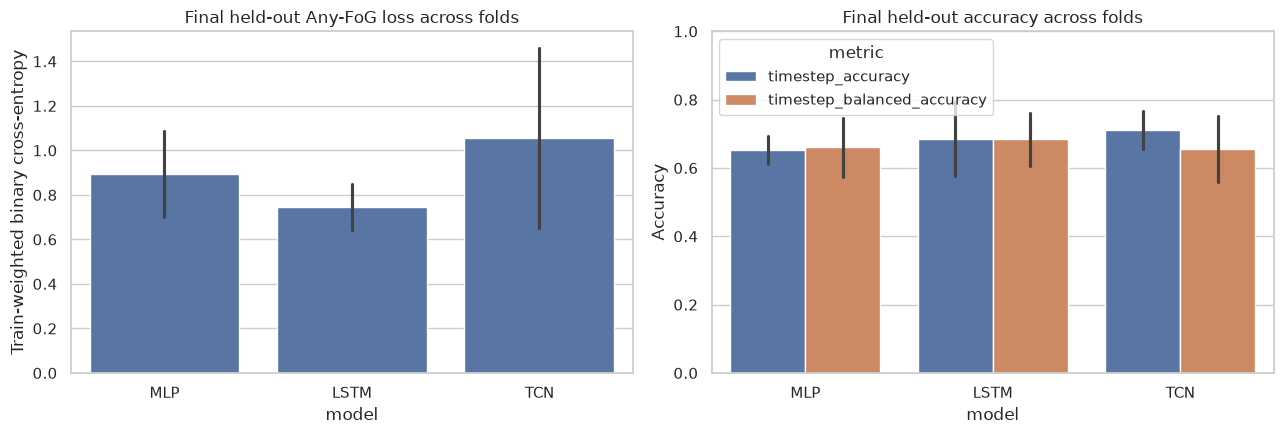

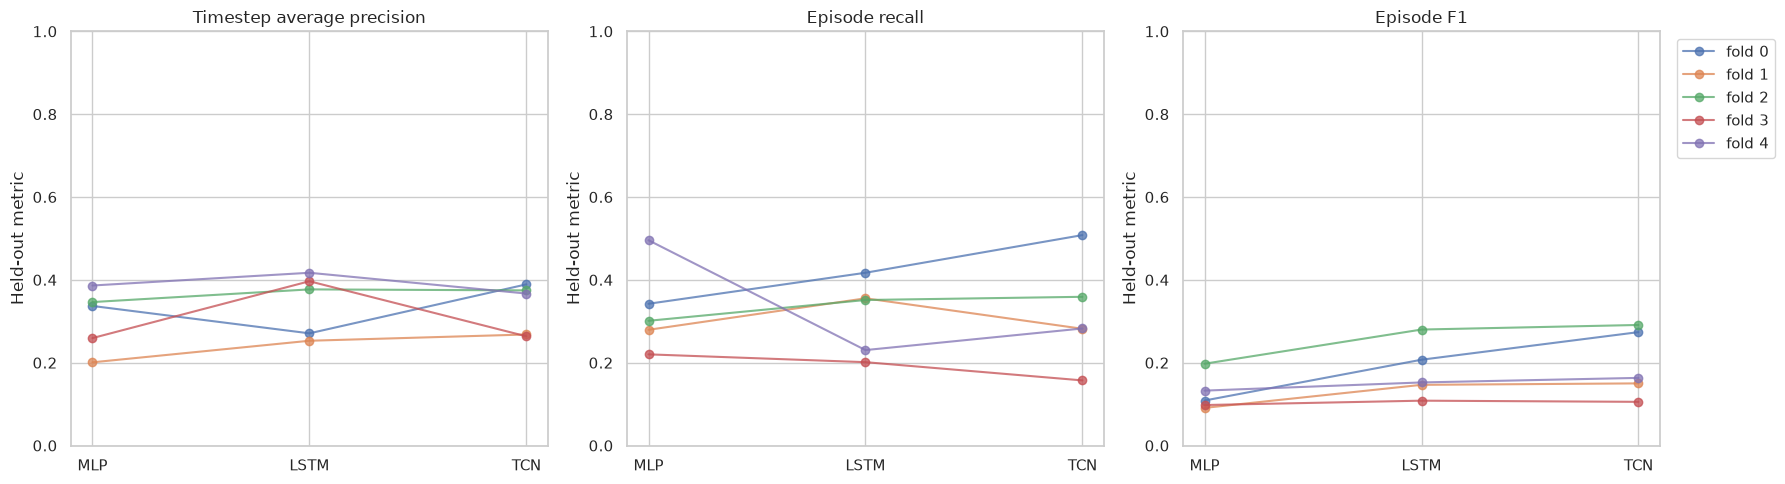

In [19]:
fold_primary = benchmark_results.fold_results.loc[
    benchmark_results.fold_results["operating_point"] == PRIMARY_OPERATING_POINT
].copy()
display(
    fold_primary.loc[
        :,
        [
            "outer_fold",
            "model",
            "average_precision",
            "test_weighted_fog_loss",
            "matched_episodes",
            "true_episodes",
            "episode_recall",
            "episode_precision",
            "episode_f1",
            "false_alarms_per_minute",
            "timestep_accuracy",
        ],
    ].sort_values(["outer_fold", "model"], kind="stable")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(
    data=fold_primary,
    x="model",
    y="test_weighted_fog_loss",
    order=ARCHITECTURES,
    errorbar="sd",
    ax=axes[0],
)
axes[0].set_title("Final held-out Any-FoG loss across folds")
axes[0].set_ylabel("Train-weighted binary cross-entropy")

held_out_accuracy = fold_primary.melt(
    id_vars=["outer_fold", "model"],
    value_vars=["timestep_accuracy", "timestep_balanced_accuracy"],
    var_name="metric",
    value_name="value",
)
sns.barplot(
    data=held_out_accuracy,
    x="model",
    y="value",
    hue="metric",
    order=ARCHITECTURES,
    errorbar="sd",
    ax=axes[1],
)
axes[1].set_ylim(0, 1)
axes[1].set_title("Final held-out accuracy across folds")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

paired_metrics = [
    ("average_precision", "Timestep average precision"),
    ("episode_recall", "Episode recall"),
    ("episode_f1", "Episode F1"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_positions = {model: index for index, model in enumerate(ARCHITECTURES)}
for axis, (metric, title) in zip(axes, paired_metrics):
    for outer_fold, fold_frame in fold_primary.groupby("outer_fold", observed=True):
        ordered = fold_frame.set_index("model").reindex(ARCHITECTURES)
        axis.plot(
            range(len(ARCHITECTURES)),
            ordered[metric],
            marker="o",
            alpha=0.75,
            label=f"fold {outer_fold}",
        )
    axis.set_xticks(range(len(ARCHITECTURES)), ARCHITECTURES)
    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.set_ylabel("Held-out metric")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 14. Precision-recall curves within each outer fold

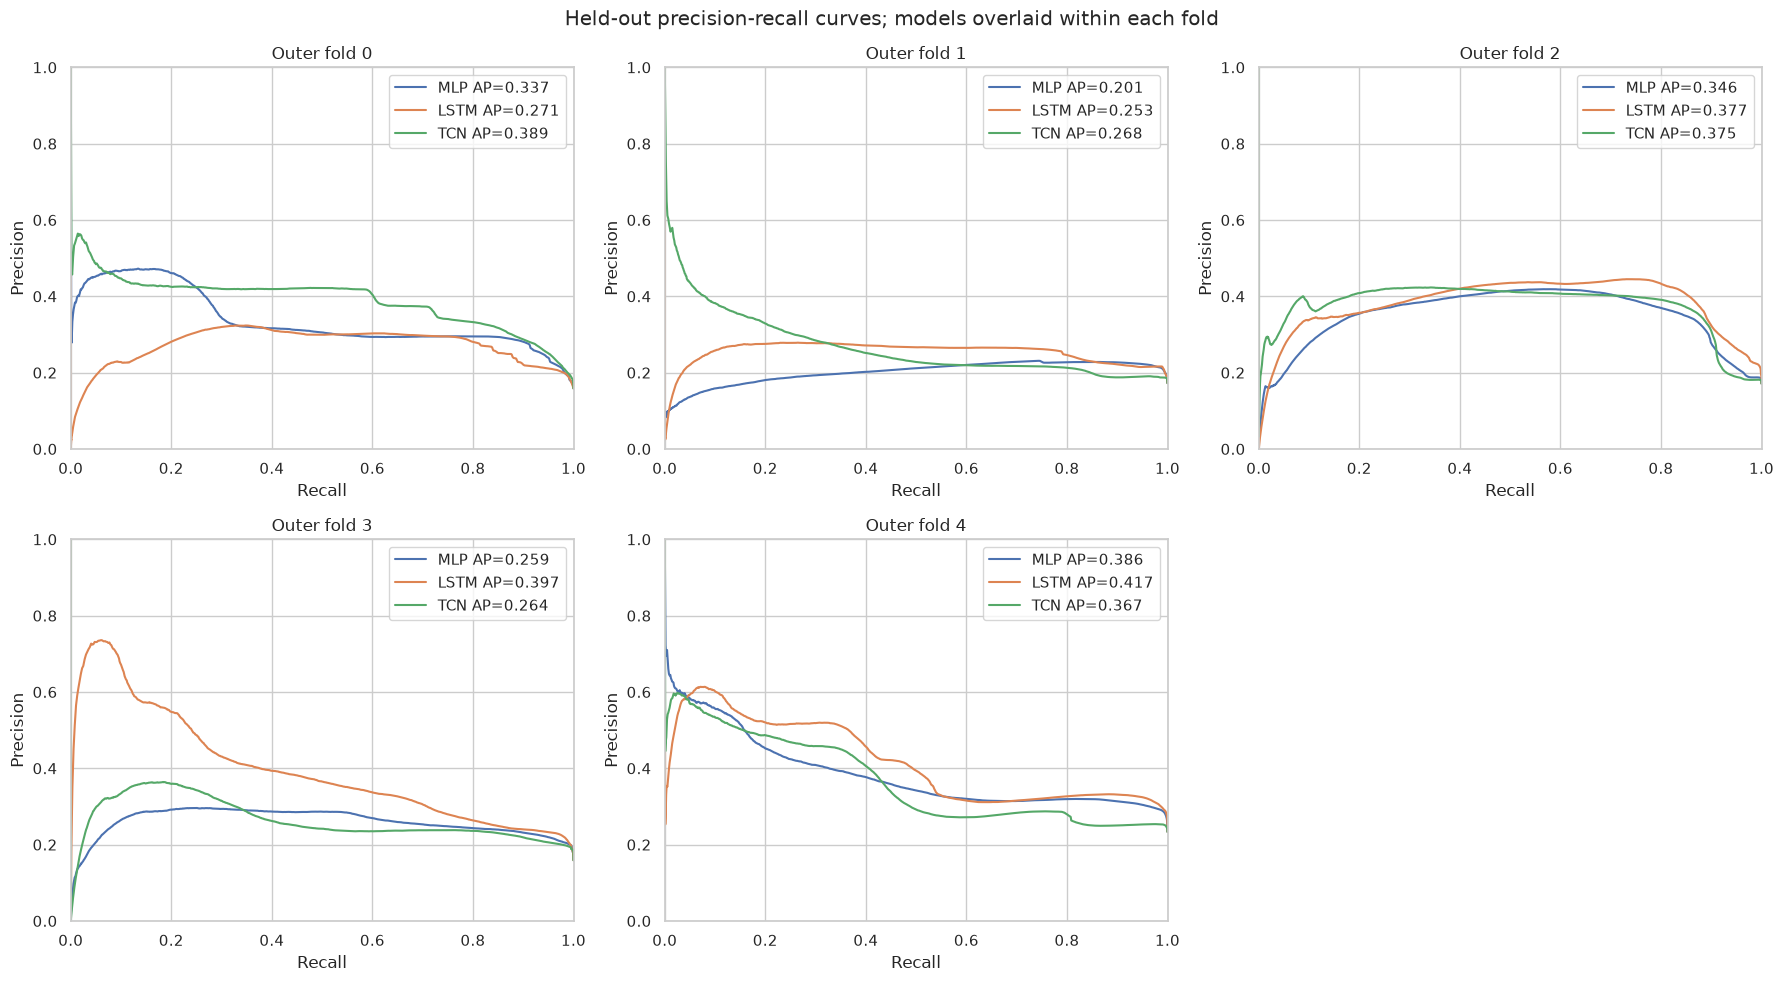

In [20]:
folds = sorted(benchmark_results.pr_curves["outer_fold"].unique())
column_count = min(3, len(folds))
row_count = int(np.ceil(len(folds) / column_count))
fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(6 * column_count, 5 * row_count),
    squeeze=False,
)
for axis, outer_fold in zip(axes.flat, folds):
    for architecture in ARCHITECTURES:
        curve = benchmark_results.pr_curves.loc[
            (benchmark_results.pr_curves["outer_fold"] == outer_fold)
            & (benchmark_results.pr_curves["model"] == architecture)
        ]
        ap = fold_primary.loc[
            (fold_primary["outer_fold"] == outer_fold)
            & (fold_primary["model"] == architecture),
            "average_precision",
        ].iloc[0]
        axis.plot(curve["recall"], curve["precision"], label=f"{architecture} AP={ap:.3f}")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.set_title(f"Outer fold {outer_fold}")
    axis.set_xlabel("Recall")
    axis.set_ylabel("Precision")
    axis.legend()
for axis in axes.flat[len(folds):]:
    axis.set_visible(False)
fig.suptitle("Held-out precision-recall curves; models overlaid within each fold")
plt.tight_layout()
plt.show()

## 15. Secondary timestep confusion matrices and accuracy

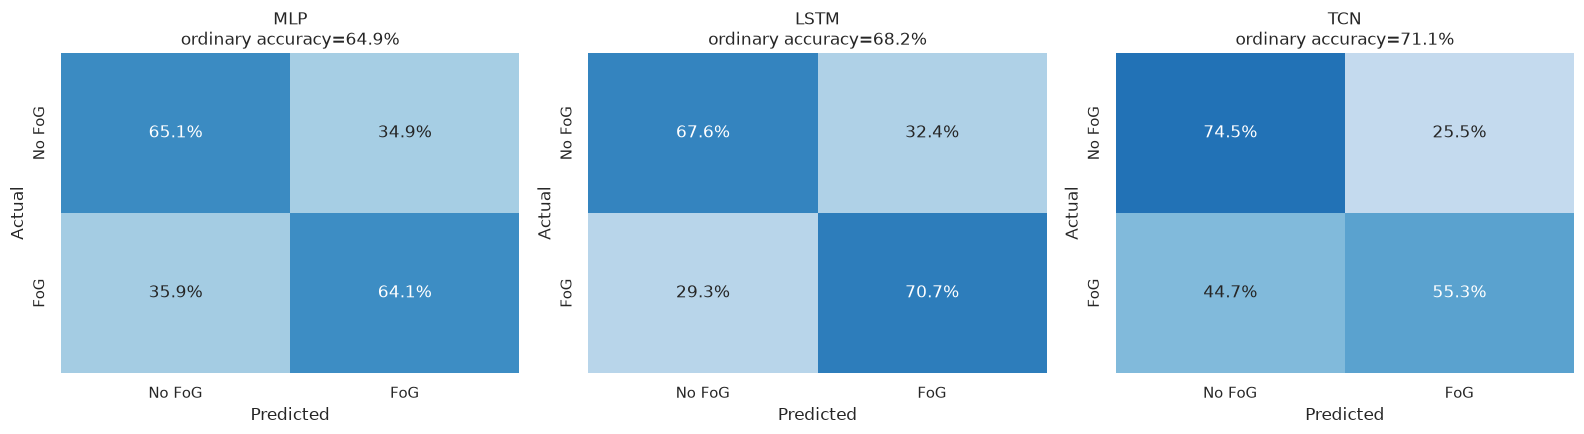

In [15]:
confusion = benchmark_results.confusion_counts.loc[
    benchmark_results.confusion_counts["operating_point"] == PRIMARY_OPERATING_POINT
]
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(16, 4.5))
for axis, architecture in zip(axes, ARCHITECTURES):
    counts = confusion.loc[confusion["model"] == architecture, ["tn", "fp", "fn", "tp"]].sum()
    matrix = np.array([[counts["tn"], counts["fp"]], [counts["fn"], counts["tp"]]], dtype=float)
    row_normalised = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    accuracy = np.trace(matrix) / matrix.sum()
    sns.heatmap(
        row_normalised,
        annot=True,
        fmt=".1%",
        vmin=0,
        vmax=1,
        cmap="Blues",
        cbar=False,
        xticklabels=["No FoG", "FoG"],
        yticklabels=["No FoG", "FoG"],
        ax=axis,
    )
    axis.set_title(f"{architecture}\nordinary accuracy={accuracy:.1%}")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 16. Held-out subject variability and denominator check

PASS: every model used the same per-subject episode denominator and duration.


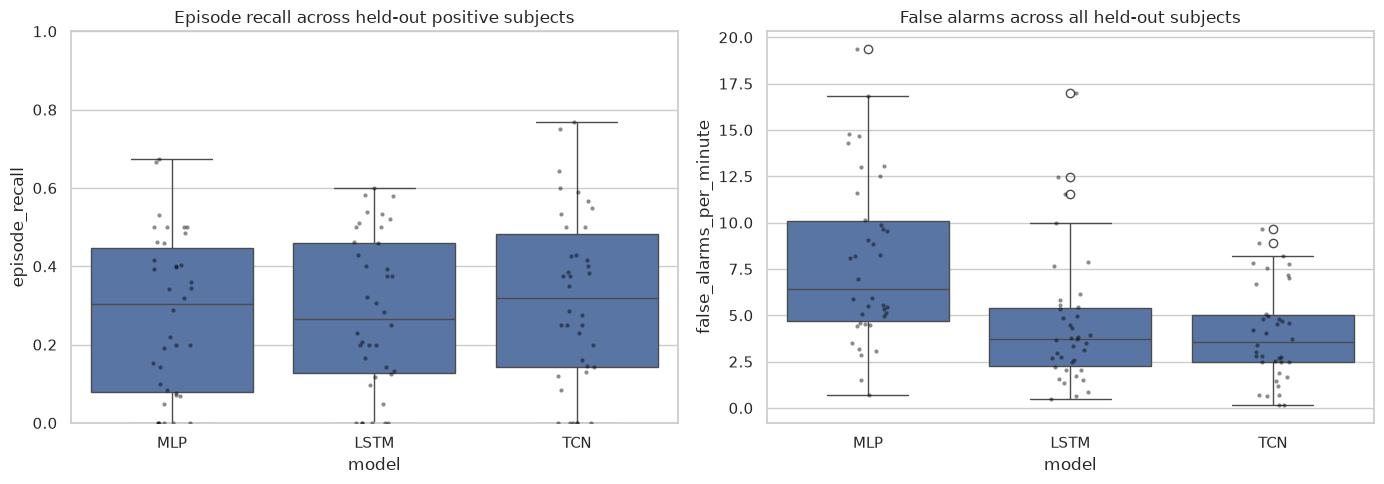

In [16]:
subject_primary = benchmark_results.subject_results.loc[
    benchmark_results.subject_results["operating_point"] == PRIMARY_OPERATING_POINT
].copy()
denominator_check = (
    subject_primary.groupby(["outer_fold", "Subject"], observed=True)
    .agg(
        true_episode_versions=("true_episodes", "nunique"),
        duration_versions=("evaluation_minutes", "nunique"),
        model_versions=("model", "nunique"),
    )
)
assert denominator_check["true_episode_versions"].max() == 1
assert denominator_check["duration_versions"].max() == 1
assert denominator_check["model_versions"].min() == len(ARCHITECTURES)
print("PASS: every model used the same per-subject episode denominator and duration.")

positive_subjects = subject_primary.loc[subject_primary["true_episodes"] > 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=positive_subjects, x="model", y="episode_recall", ax=axes[0])
sns.stripplot(
    data=positive_subjects,
    x="model",
    y="episode_recall",
    color="black",
    alpha=0.45,
    size=3,
    ax=axes[0],
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Episode recall across held-out positive subjects")

sns.boxplot(
    data=subject_primary,
    x="model",
    y="false_alarms_per_minute",
    ax=axes[1],
)
sns.stripplot(
    data=subject_primary,
    x="model",
    y="false_alarms_per_minute",
    color="black",
    alpha=0.45,
    size=3,
    ax=axes[1],
)
axes[1].set_title("False alarms across all held-out subjects")
plt.tight_layout()
plt.show()

## 17. Calibration-selected decoder thresholds

In [17]:
selected_decoder_rows = benchmark_results.decoder_tables.loc[
    benchmark_results.decoder_tables["selected_macro_f1"]
    | benchmark_results.decoder_tables["selected_alarm_budget"]
].copy()
display(
    selected_decoder_rows.loc[
        :,
        [
            "outer_fold",
            "model",
            "on_threshold",
            "off_threshold",
            "selected_macro_f1",
            "selected_alarm_budget",
            "alarm_budget_was_feasible",
            "macro_episode_recall",
            "macro_episode_f1",
            "macro_false_alarms_per_minute",
        ],
    ].sort_values(["outer_fold", "model", "on_threshold"], kind="stable")
)

,outer_fold,model,on_threshold,off_threshold,selected_macro_f1,selected_alarm_budget,alarm_budget_was_feasible,macro_episode_recall,macro_episode_f1,macro_false_alarms_per_minute
9,0,LSTM,0.20,0.10,True,False,True,0.384245,0.173380,6.286065
15,0,LSTM,0.80,0.70,False,True,True,0.072655,0.102624,0.478328
0,0,MLP,0.20,0.10,True,False,True,0.285940,0.108754,7.783814
6,0,MLP,0.80,0.70,False,True,True,0.003817,0.005076,0.812333
18,0,TCN,0.20,0.10,True,False,True,0.213158,0.156168,2.741706
23,0,TCN,0.70,0.60,False,True,True,0.050605,0.059927,0.754384
37,1,LSTM,0.30,0.20,True,False,True,0.559592,0.286539,4.899957
43,1,LSTM,0.90,0.80,False,True,True,0.022436,0.028689,0.692196
27,1,MLP,0.20,0.10,True,False,True,0.500160,0.179767,9.026837
35,1,MLP,0.99,0.89,False,True,True,0.000000,0.000000,0.000000


## 18. Save compact result tables

In [18]:
RESULTS_DIR = (
    PROJECT_ROOT / "results" / "model_comparison" / DATASET_NAME / RUN_PROFILE
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "subject_fold_manifest": subject_manifest,
    "model_parameters": benchmark_results.model_parameters.reset_index(),
    "fold_partitions": benchmark_results.fold_partitions,
    "fold_results": benchmark_results.fold_results,
    "overall_results": benchmark_results.overall_results.reset_index(),
    "subject_results": benchmark_results.subject_results,
    "decoder_calibration": benchmark_results.decoder_tables,
    "confusion_counts": benchmark_results.confusion_counts,
    "pr_curves": benchmark_results.pr_curves,
    "episode_matches": benchmark_results.matches,
    "training_history": benchmark_results.histories,
}
for table_name, table in tables_to_save.items():
    table_to_write = table.copy()
    if "dataset" not in table_to_write.columns:
        table_to_write.insert(0, "dataset", DATASET_NAME)
    table_to_write.to_csv(RESULTS_DIR / f"{table_name}.csv", index=False)

run_configuration = pd.DataFrame(
    [
        {
            "dataset": DATASET_NAME,
            "profile": RUN_PROFILE,
            "native_sampling_rate_hz": SETTINGS.native_sampling_rate_hz,
            "benchmark_sampling_rate_hz": SETTINGS.benchmark_sampling_rate_hz,
            "window_seconds": SETTINGS.window_seconds,
            "folds": str(SETTINGS.folds_to_run),
            "seeds": str(SETTINGS.ensemble_seeds),
            "maximum_epochs": SETTINGS.epochs,
            "early_stopping_patience": SETTINGS.early_stopping_patience,
            "episode_iou_threshold": SETTINGS.episode_iou_threshold,
            "false_alarm_budget_per_minute": SETTINGS.false_alarm_budget_per_minute,
        }
    ]
)
run_configuration.to_csv(RESULTS_DIR / "run_configuration.csv", index=False)
print(f"Saved compact benchmark tables to: {RESULTS_DIR}")

Saved compact benchmark tables to: /mnt/d/Dissertation/results/model_comparison/defog/comparison


## 19. Interpretation rules

- Use correctly detected / actual episodes and episode recall to answer
  how often the system catches a real gait episode.
- Read recall alongside precision and false alarms per minute. A detector
  that predicts FoG constantly can have high recall but little value.
- Compare the three models within this notebook. Do not pool DeFOG and
  TDCS scores; they are different subject populations and experiments.
- Fold average precision is averaged from five separate held-out folds;
  raw probabilities from different fold models are never pooled for AP.
- These 25 Hz, two-second-window denominators differ slightly from the old
  native-rate notebooks, so old and new episode counts are not directly
  interchangeable.
- Earlier TCN held-out plots have already been inspected. This is now a
  frozen retrospective benchmark, not a pristine never-inspected lockbox.
  Do not alter features, folds, decoder, or metrics after viewing results.